# Spaceship Titanic 생존 예측 프로젝트

## 프로젝트 목표

Spaceship Titanic 데이터셋을 활용하여 승객이 다른 차원으로 이동(Transported)되었는지 예측하는 머신러닝 모델을 구축한다.

## 사용 데이터

- train.csv : 학습 데이터
- test.csv : 예측 데이터
- sample_submission.csv : 제출 형식

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

데이터 확인
# 데이터 탐색 (EDA)

데이터의 구조와 결측치를 확인하고 각 변수의 특성을 분석하였다.

주요 변수

- PassengerId (승객 ID)
- HomePlanet (출신 행성)
- CryoSleep (냉동 수면 상태)
- Cabin (객실 정보)
- Destination (목적지)
- Age (나이)
- VIP (귀빈 여부)
- RoomService (룸서비스 사용 금액)
- FoodCourt (식당 사용 금액)
- ShoppingMall (쇼핑몰 사용 금액)
- Spa (스파 사용 금액)
- VRDeck (가상현실 시설 사용 금액)
- Transported (목표 변수)

TRAIN HEAD


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
MISSING VALUES


CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

TARGET DISTRIBUTION


Transported
True     4378
False    4315
Name: count, dtype: int64

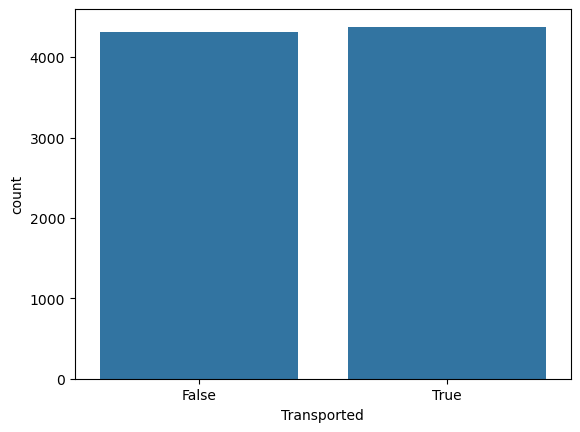

In [4]:
# 데이터 불러오기
train = pd.read_csv('data01/train.csv')
test = pd.read_csv('data01/test.csv')
sample = pd.read_csv('data01/sample_submission.csv')

# 데이터 확인
print("="*50)
print("TRAIN HEAD")
display(train.head())

print("="*50)
print("TRAIN INFO")
train.info()

print("="*50)
print("MISSING VALUES")
display(train.isnull().sum().sort_values(ascending=False))

print("="*50)
print("TARGET DISTRIBUTION")
display(train['Transported'].value_counts())

# 타겟 시각화
sns.countplot(data=train, x='Transported')
plt.show()

그래프 분석 후

# EDA 결과 분석

## CryoSleep (냉동 수면 상태)

CryoSleep 상태인 승객은 Transported 비율이 높게 나타났다.

## HomePlanet (출신 행성)

Europa 출신 승객의 Transported 비율이 상대적으로 높게 나타났다.

## VIP (귀빈 여부)

VIP 여부는 Transported 여부에 큰 영향을 미치지 않는 것으로 보인다.

## Age (나이)

어린 연령대 승객의 Transported 비율이 상대적으로 높게 나타났다.

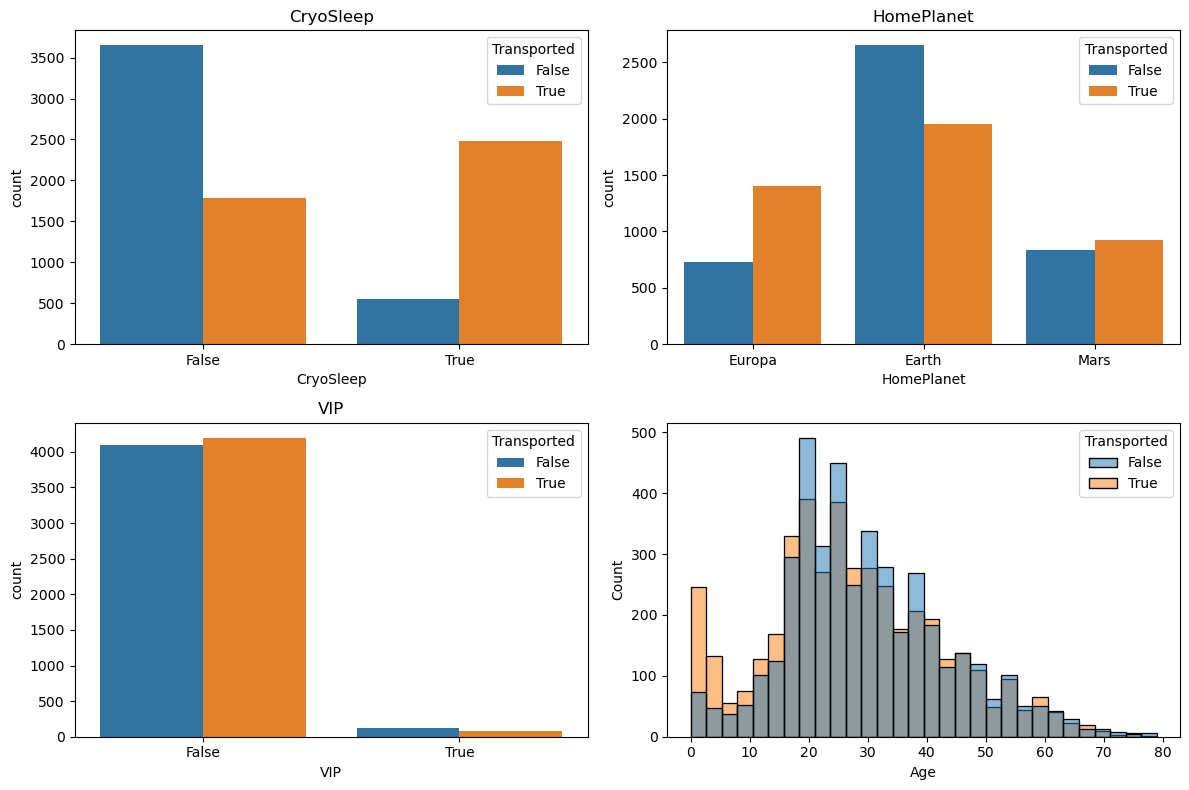

In [5]:
# EDA 시각화

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=train, x='CryoSleep', hue='Transported', ax=axes[0,0])
axes[0,0].set_title('CryoSleep')

sns.countplot(data=train, x='HomePlanet', hue='Transported', ax=axes[0,1])
axes[0,1].set_title('HomePlanet')

sns.countplot(data=train, x='VIP', hue='Transported', ax=axes[1,0])
axes[1,0].set_title('VIP')

sns.histplot(data=train, x='Age', hue='Transported', bins=30, ax=axes[1,1])

plt.tight_layout()
plt.show()

Random Forest 모델을 사용하여 승객의 Transported 여부를 예측하였다.

Random Forest는 여러 개의 의사결정나무를 활용하여 예측 성능을 높이는 앙상블 학습 기법이다.

In [6]:
# 결측치 처리
train = train.copy()
test = test.copy()

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = train[col].fillna('Unknown')
    else:
        train[col] = train[col].fillna(train[col].median())

for col in test.columns:
    if test[col].dtype == 'object':
        test[col] = test[col].fillna('Unknown')
    else:
        test[col] = test[col].fillna(test[col].median())

# PassengerId 제거
train = train.drop('PassengerId', axis=1)
test_ids = test['PassengerId']
test = test.drop('PassengerId', axis=1)

# 원핫 인코딩
all_data = pd.concat([train.drop('Transported', axis=1), test])

all_data = pd.get_dummies(all_data)

X = all_data.iloc[:len(train)]
X_test = all_data.iloc[len(train):]

y = train['Transported']

print(X.shape)
print(X_test.shape)

(8693, 22476)
(4277, 22476)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 모델 생성
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 학습
model.fit(X_train, y_train)

# 검증
pred = model.predict(X_valid)

accuracy = accuracy_score(y_valid, pred)

print("Accuracy (정확도):", accuracy)

Accuracy (정확도): 0.7855089131684876


정확도 결과

검증 데이터 기준 Accuracy는 약 0.7855로 나타났다.

약 78.55%의 승객 이동 여부를 올바르게 예측하였다

In [9]:
# 테스트 데이터 예측
test_pred = model.predict(X_test)

# 제출 파일 생성
submission = pd.DataFrame({
    'PassengerId': sample['PassengerId'],
    'Transported': test_pred
})

submission.to_csv('submission.csv', index=False)

submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


본 프로젝트에서는 Spaceship Titanic 데이터를 활용하여 승객의 이동 여부를 예측하는 머신러닝 모델을 구축하였다.

EDA 결과 CryoSleep과 HomePlanet이 중요한 변수로 확인되었으며, Random Forest 모델을 사용하여 약 78.55%의 정확도를 달성하였다.

추가적인 특성 엔지니어링과 하이퍼파라미터 튜닝을 수행하면 성능 향상이 가능할 것으로 예상된다.

In [10]:
submission.shape

(4277, 2)

In [11]:
import os
os.listdir()

['.ipynb_checkpoints',
 'spaceship-titanic.zip',
 'submission.csv',
 'README.md',
 'data01',
 'Quest.ipynb']

In [12]:
!ls

Quest.ipynb  README.md	data01	spaceship-titanic.zip  submission.csv


회고 

Spaceship Titanic Project
프로젝트 개요

Spaceship Titanic 데이터셋을 활용하여 승객의 Transported 여부를 예측하는 머신러닝 모델을 구축하였다.

사용 데이터
train.csv
test.csv
sample_submission.csv
EDA 결과
CryoSleep (냉동 수면 상태)

CryoSleep 상태인 승객은 Transported 비율이 높게 나타났다.

HomePlanet (출신 행성)

Europa 출신 승객의 Transported 비율이 상대적으로 높게 나타났다.

VIP (귀빈 여부)

VIP 여부는 Transported 여부와 큰 관련성을 보이지 않았다.

Age (나이)

어린 연령대 승객의 Transported 비율이 상대적으로 높게 나타났다.

데이터 전처리
결측치 처리
범주형 데이터 인코딩
불필요한 컬럼 제거
학습 데이터와 테스트 데이터 컬럼 정렬
모델

RandomForestClassifier를 사용하여 학습을 수행하였다.

결과
Accuracy : 0.7855
결론

CryoSleep과 HomePlanet이 중요한 변수로 확인되었으며, Random Forest 모델을 활용하여 승객 이동 여부를 예측할 수 있었다.